In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from funcoes.funcoes_feat_eng import *
import math 

# Novas colunas

In [2]:
df = pd.read_csv('../processed/df_clean.csv', sep=';', encoding='utf-8-sig')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21607,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21608,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21609,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21610,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [3]:
# Correção do datetime
df_clean = colunas_datetime(df)

In [4]:
df_clean.columns

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'ano', 'mes', 'dia_da_semana',
       'trimestre', 'final_de_semana', 'fim_do_mes', 'hora', 'semestre',
       'dias_desde_inicio', 'estacao_Primavera', 'estacao_Verao',
       'estacao_Outono', 'estacao_Inverno'],
      dtype='object')

In [5]:
df_novascolunas = df_clean.copy()
#-------------------------------------------------------------------------
df_novascolunas['sqft_lot_more_living'] = (df_novascolunas['sqft_living'] + df_novascolunas['sqft_lot']).round(4)
df_novascolunas['living_percent_total'] = (df_novascolunas['sqft_living'] / df_novascolunas['sqft_lot_more_living']).round(4)
#-------------------------------------------------------------------------
df_novascolunas['percent_construcao_above'] = (df_novascolunas['sqft_above']/df_novascolunas['sqft_living']).round(4)
#-------------------------------------------------------------------------
df_novascolunas['lot_15_compare'] =  (df_novascolunas['sqft_lot']/df_novascolunas['sqft_lot15']).round(4)
df_novascolunas['living_15_compare'] = (df_novascolunas['sqft_living']/df_novascolunas['sqft_living15']).round(4)
#-------------------------------------------------------------------------
df_novascolunas['mean_price_zipcode'] = (df_novascolunas.groupby('zipcode')['price'].transform('mean')).round(4)
#-------------------------------------------------------------------------
df_novascolunas['age'] = 2026 - df_novascolunas['yr_built']

df_novascolunas['age_renovated'] = np.where(
    df_novascolunas['yr_renovated'] == 0, 
    df_novascolunas['age'], 
    2026 - df_novascolunas['yr_renovated']
).round(2)
#-------------------------------------------------------------------------
df_novascolunas['bath_per_bed'] = np.where(
    df_novascolunas['bedrooms'] > 0,
    (df_novascolunas['bathrooms'] / df_novascolunas['bedrooms']).round(4),
    df_novascolunas['bathrooms'])
df_novascolunas['bed_per_floor'] = np.where(
    df_novascolunas['bedrooms'] > 0,
    (df_novascolunas['bedrooms'] / df_novascolunas['floors']).round(4),
    df_novascolunas['bedrooms'])
#-------------------------------------------------------------------------
df_novascolunas['grade_x_condition'] = df_novascolunas['grade'] * df_novascolunas['condition']
#-------------------------------------------------------------------------
df_novascolunas['bool_renovated'] = np.where(df_novascolunas['yr_renovated'] > 0, 1, 0)
df_novascolunas['bool_basement'] = np.where(df_novascolunas['sqft_basement'] > 0, 1, 0)
df_novascolunas['living_more_than_lot'] = np.where(df_novascolunas['sqft_living'] >= df_novascolunas['sqft_lot'], 1, 0)
#-------------------------------------------------------------------------
# Cidades próximas
seattle_lat, seattle_long = 47.6062, -122.3321
df_novascolunas['dist_seattle'] = np.sqrt(
    (df_novascolunas['lat'] - seattle_lat)**2 + 
    (df_novascolunas['long'] - seattle_long)**2
).round(4)
Bellevue_lat, Bellevue_long = 47.6101, -122.2015
df_novascolunas['dist_Bellevue'] = np.sqrt(
    (df_novascolunas['lat'] - Bellevue_lat)**2 + 
    (df_novascolunas['long'] - Bellevue_long)**2
).round(4)
Redmond_lat, Redmond_long = 47.6740, -122.1215
df_novascolunas['dist_Redmond'] = np.sqrt(
    (df_novascolunas['lat'] - Redmond_lat)**2 + 
    (df_novascolunas['long'] - Redmond_long)**2
).round(4)
# Pontos turisticos
Snoqualmie_lat, Snoqualmie_long = 47.5417, -121.8373
df_novascolunas['dist_Snoqualmie'] = np.sqrt(
    (df_novascolunas['lat'] - Snoqualmie_lat)**2 + 
    (df_novascolunas['long'] - Snoqualmie_long)**2
).round(4)
Mountdaniel_lat, Mountdaniel_long = 47.5615, -121.1323
df_novascolunas['dist_Snoqualmie'] = np.sqrt(
    (df_novascolunas['lat'] - Mountdaniel_lat)**2 + 
    (df_novascolunas['long'] - Mountdaniel_long)**2
).round(4)
vashonisland_lat, vashonisland_long = 47.4165, -122.4645
df_novascolunas['dist_Snoqualmie'] = np.sqrt(
    (df_novascolunas['lat'] - vashonisland_lat)**2 + 
    (df_novascolunas['long'] - vashonisland_long)**2
).round(4)
# Infraestrutura
aeroporto_SeaTac_lat, aeroporto_SeaTac_long = 47.4502, -122.3088
df_novascolunas['dist_Snoqualmie'] = np.sqrt(
    (df_novascolunas['lat'] - aeroporto_SeaTac_lat)**2 + 
    (df_novascolunas['long'] - aeroporto_SeaTac_long)**2
).round(4)



In [6]:
# Confirmando range
df_novascolunas['age_renovated'].describe()

count    21612.000000
mean        52.612761
std         28.806961
min         11.000000
25%         27.000000
50%         49.000000
75%         72.000000
max        126.000000
Name: age_renovated, dtype: float64

In [7]:
df_novascolunas['bool_renovated_45'] = np.where(df_novascolunas['age_renovated'] < 45, 1, 0)
df_novascolunas['bool_renovated_15'] = np.where(df_novascolunas['age_renovated'] < 15, 1, 0)

In [8]:
df_novascolunas.columns

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'ano', 'mes', 'dia_da_semana',
       'trimestre', 'final_de_semana', 'fim_do_mes', 'hora', 'semestre',
       'dias_desde_inicio', 'estacao_Primavera', 'estacao_Verao',
       'estacao_Outono', 'estacao_Inverno', 'sqft_lot_more_living',
       'living_percent_total', 'percent_construcao_above', 'lot_15_compare',
       'living_15_compare', 'mean_price_zipcode', 'age', 'age_renovated',
       'bath_per_bed', 'bed_per_floor', 'grade_x_condition', 'bool_renovated',
       'bool_basement', 'living_more_than_lot', 'dist_seattle',
       'dist_Bellevue', 'dist_Redmond', 'dist_Snoqualmie', 'bool_renovated_45',
       'bool_renovated_15'],
      dtype='object')

In [9]:
# Multiplicação de colunas relevantes para o modelo
df_novascolunas['waterfront_grade'] = df_novascolunas['waterfront'] * df_novascolunas['grade']
df_novascolunas['living_grade'] = df_novascolunas['sqft_living'] * df_novascolunas['grade']
df_novascolunas['living_waterffront'] = df_novascolunas['sqft_living'] * df_novascolunas['waterfront']
df_novascolunas['waterfront_condition'] = df_novascolunas['waterfront'] * df_novascolunas['condition']
df_novascolunas['luxury'] = df_novascolunas['grade'] * df_novascolunas['mean_price_zipcode']*df_novascolunas['sqft_living']*df_novascolunas['condition']


In [10]:
df_novascolunas.to_csv('df_novascolunas.csv', index=False, sep=';', encoding='utf-8-sig')

# 1º Limpeza de colunas

In [11]:
df_novascolunas.columns

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'ano', 'mes', 'dia_da_semana',
       'trimestre', 'final_de_semana', 'fim_do_mes', 'hora', 'semestre',
       'dias_desde_inicio', 'estacao_Primavera', 'estacao_Verao',
       'estacao_Outono', 'estacao_Inverno', 'sqft_lot_more_living',
       'living_percent_total', 'percent_construcao_above', 'lot_15_compare',
       'living_15_compare', 'mean_price_zipcode', 'age', 'age_renovated',
       'bath_per_bed', 'bed_per_floor', 'grade_x_condition', 'bool_renovated',
       'bool_basement', 'living_more_than_lot', 'dist_seattle',
       'dist_Bellevue', 'dist_Redmond', 'dist_Snoqualmie', 'bool_renovated_45',
       'bool_renovated_15', 'waterfront_grade', 'living_grade',
       'living_waterffront', 'waterfront_condition', 'luxur

In [12]:
limpeza_colunas = ['id','yr_built','zipcode','lat','long','hora']

df_colunas_necessarias = df_novascolunas.drop(columns=limpeza_colunas)
df_colunas_necessarias

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,dist_Bellevue,dist_Redmond,dist_Snoqualmie,bool_renovated_45,bool_renovated_15,waterfront_grade,living_grade,living_waterffront,waterfront_condition,luxury
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0.1134,0.2118,0.0800,0,0,0,8260,0,0,7.696984e+09
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,0.1616,0.2030,0.2710,1,0,0,17990,0,0,2.533653e+10
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0.1316,0.1285,0.2975,0,0,0,4620,0,0,6.409973e+09
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,0.2113,0.3117,0.1099,0,0,0,13720,0,0,3.784584e+10
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0.1566,0.0955,0.3120,1,0,0,13440,0,0,2.764362e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21607,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,...,0.1698,0.2259,0.2519,1,0,0,12240,0,0,2.147487e+10
21608,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,...,0.1888,0.2907,0.0806,1,1,0,18480,0,0,1.992975e+10
21609,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,...,0.0988,0.1945,0.1445,1,0,0,7140,0,0,1.273521e+10
21610,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,...,0.1526,0.1491,0.2542,1,0,0,12800,0,0,2.369244e+10


In [13]:
df_colunas_necessarias.to_csv('df_colunas_filtradas.csv', index=False, sep=';', encoding='utf-8-sig')

# 2º Limpeza (Multicolinearidade)

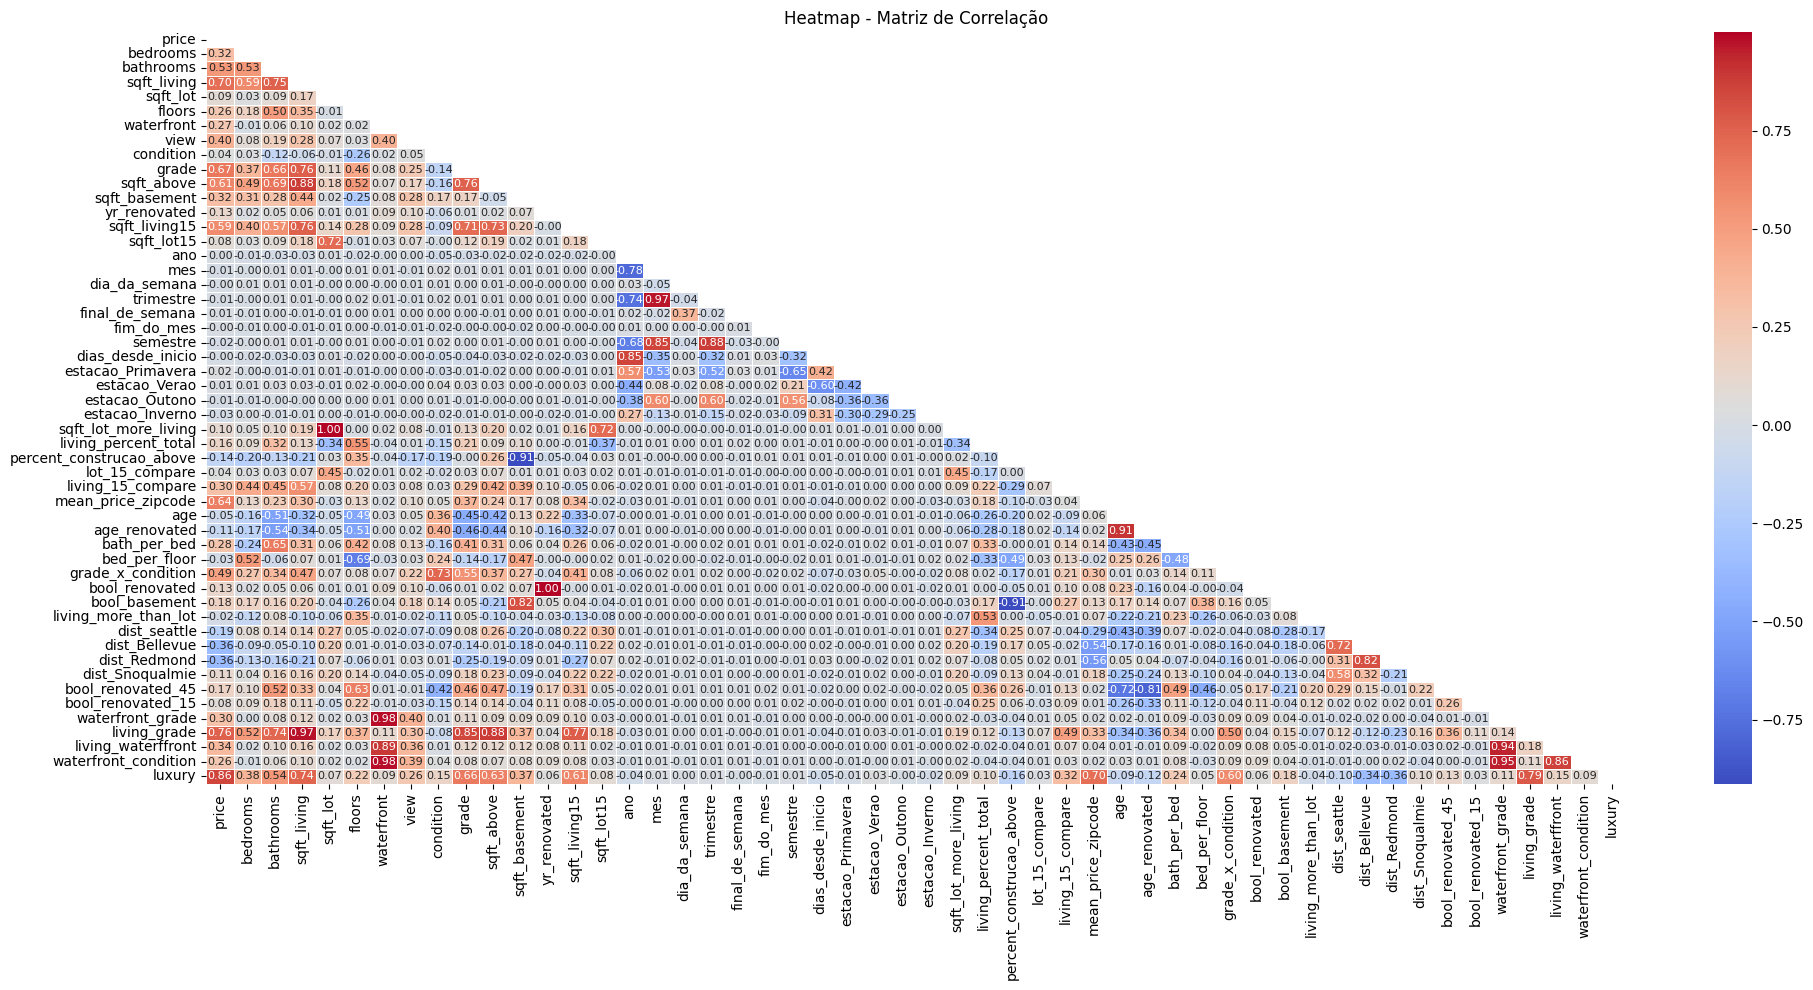

In [14]:
corr = df_colunas_necessarias.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 10))
sns.heatmap(df_colunas_necessarias.corr(), mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,annot_kws={"size": 8})
plt.title('Heatmap - Matriz de Correlação')
plt.tight_layout()
plt.show()

In [15]:
# Tratando multicolinearidade
df_heatmap = df_colunas_necessarias.copy()
lista = ['yr_renovated','bool_basement','percent_construcao_above','sqft_above','sqft_lot_more_living']
df_heatmap = df_heatmap.drop(columns=lista)
df_heatmap.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_basement',
       'sqft_living15', 'sqft_lot15', 'ano', 'mes', 'dia_da_semana',
       'trimestre', 'final_de_semana', 'fim_do_mes', 'semestre',
       'dias_desde_inicio', 'estacao_Primavera', 'estacao_Verao',
       'estacao_Outono', 'estacao_Inverno', 'living_percent_total',
       'lot_15_compare', 'living_15_compare', 'mean_price_zipcode', 'age',
       'age_renovated', 'bath_per_bed', 'bed_per_floor', 'grade_x_condition',
       'bool_renovated', 'living_more_than_lot', 'dist_seattle',
       'dist_Bellevue', 'dist_Redmond', 'dist_Snoqualmie', 'bool_renovated_45',
       'bool_renovated_15', 'waterfront_grade', 'living_grade',
       'living_waterffront', 'waterfront_condition', 'luxury'],
      dtype='object')

In [16]:
criar_painel_diagnostico(df_heatmap)

,Coluna,Assimetria (Skew),Precisa de LOG?,Qtd Outliers,% Outliers,Possível Ruído?,Ação Recomendada
23,estacao_Outono,1.25,Não,5063,23.43,Não,Suavizar Outliers (Capping)
26,lot_15_compare,31.85,SIM,3918,18.13,Não,Aplicar LOG + Suavizar Outliers (Capping)
24,estacao_Inverno,1.75,SIM,3699,17.12,Não,Aplicar LOG + Suavizar Outliers (Capping)
4,sqft_lot,13.06,SIM,2425,11.22,Não,Aplicar LOG + Suavizar Outliers (Capping)
12,sqft_lot15,9.51,SIM,2194,10.15,Não,Aplicar LOG + Suavizar Outliers (Capping)
7,view,3.40,SIM,2124,9.83,Não,Aplicar LOG + Suavizar Outliers (Capping)
9,grade,0.77,Não,1911,8.84,Não,Suavizar Outliers (Capping)
46,luxury,4.87,SIM,1573,7.28,Não,Aplicar LOG + Suavizar Outliers (Capping)
27,living_15_compare,2.03,SIM,1490,6.89,Não,Aplicar LOG + Suavizar Outliers (Capping)
0,price,4.02,SIM,1146,5.30,Não,Aplicar LOG + Suavizar Outliers (Capping)


In [17]:
# Tratamento dos zeros suspeitos
print(df_heatmap.shape)
df_heatmap = df_heatmap[(df_heatmap['bedrooms'] > 0) & (df_heatmap['bathrooms'] > 0)]
print(df_heatmap.shape)

(21612, 47)
(21596, 47)


In [18]:
df_step_1 = df_heatmap.copy()

In [19]:
obter_listas_tratamento(df_step_1)

{'log': ['price',
  'sqft_lot',
  'waterfront',
  'view',
  'sqft_basement',
  'sqft_lot15',
  'final_de_semana',
  'fim_do_mes',
  'estacao_Inverno',
  'lot_15_compare',
  'living_15_compare',
  'mean_price_zipcode',
  'bool_renovated',
  'living_more_than_lot',
  'bool_renovated_15',
  'waterfront_grade',
  'living_grade',
  'living_waterffront',
  'waterfront_condition',
  'luxury'],
 'capping': ['price',
  'sqft_lot',
  'view',
  'grade',
  'sqft_lot15',
  'estacao_Outono',
  'estacao_Inverno',
  'lot_15_compare',
  'living_15_compare',
  'bool_renovated_15',
  'luxury'],
 'extremos': ['bedrooms',
  'bathrooms',
  'sqft_living',
  'waterfront',
  'condition',
  'sqft_basement',
  'sqft_living15',
  'final_de_semana',
  'fim_do_mes',
  'living_percent_total',
  'mean_price_zipcode',
  'bath_per_bed',
  'bed_per_floor',
  'grade_x_condition',
  'bool_renovated',
  'living_more_than_lot',
  'dist_seattle',
  'dist_Bellevue',
  'dist_Redmond',
  'dist_Snoqualmie',
  'waterfront_grade',

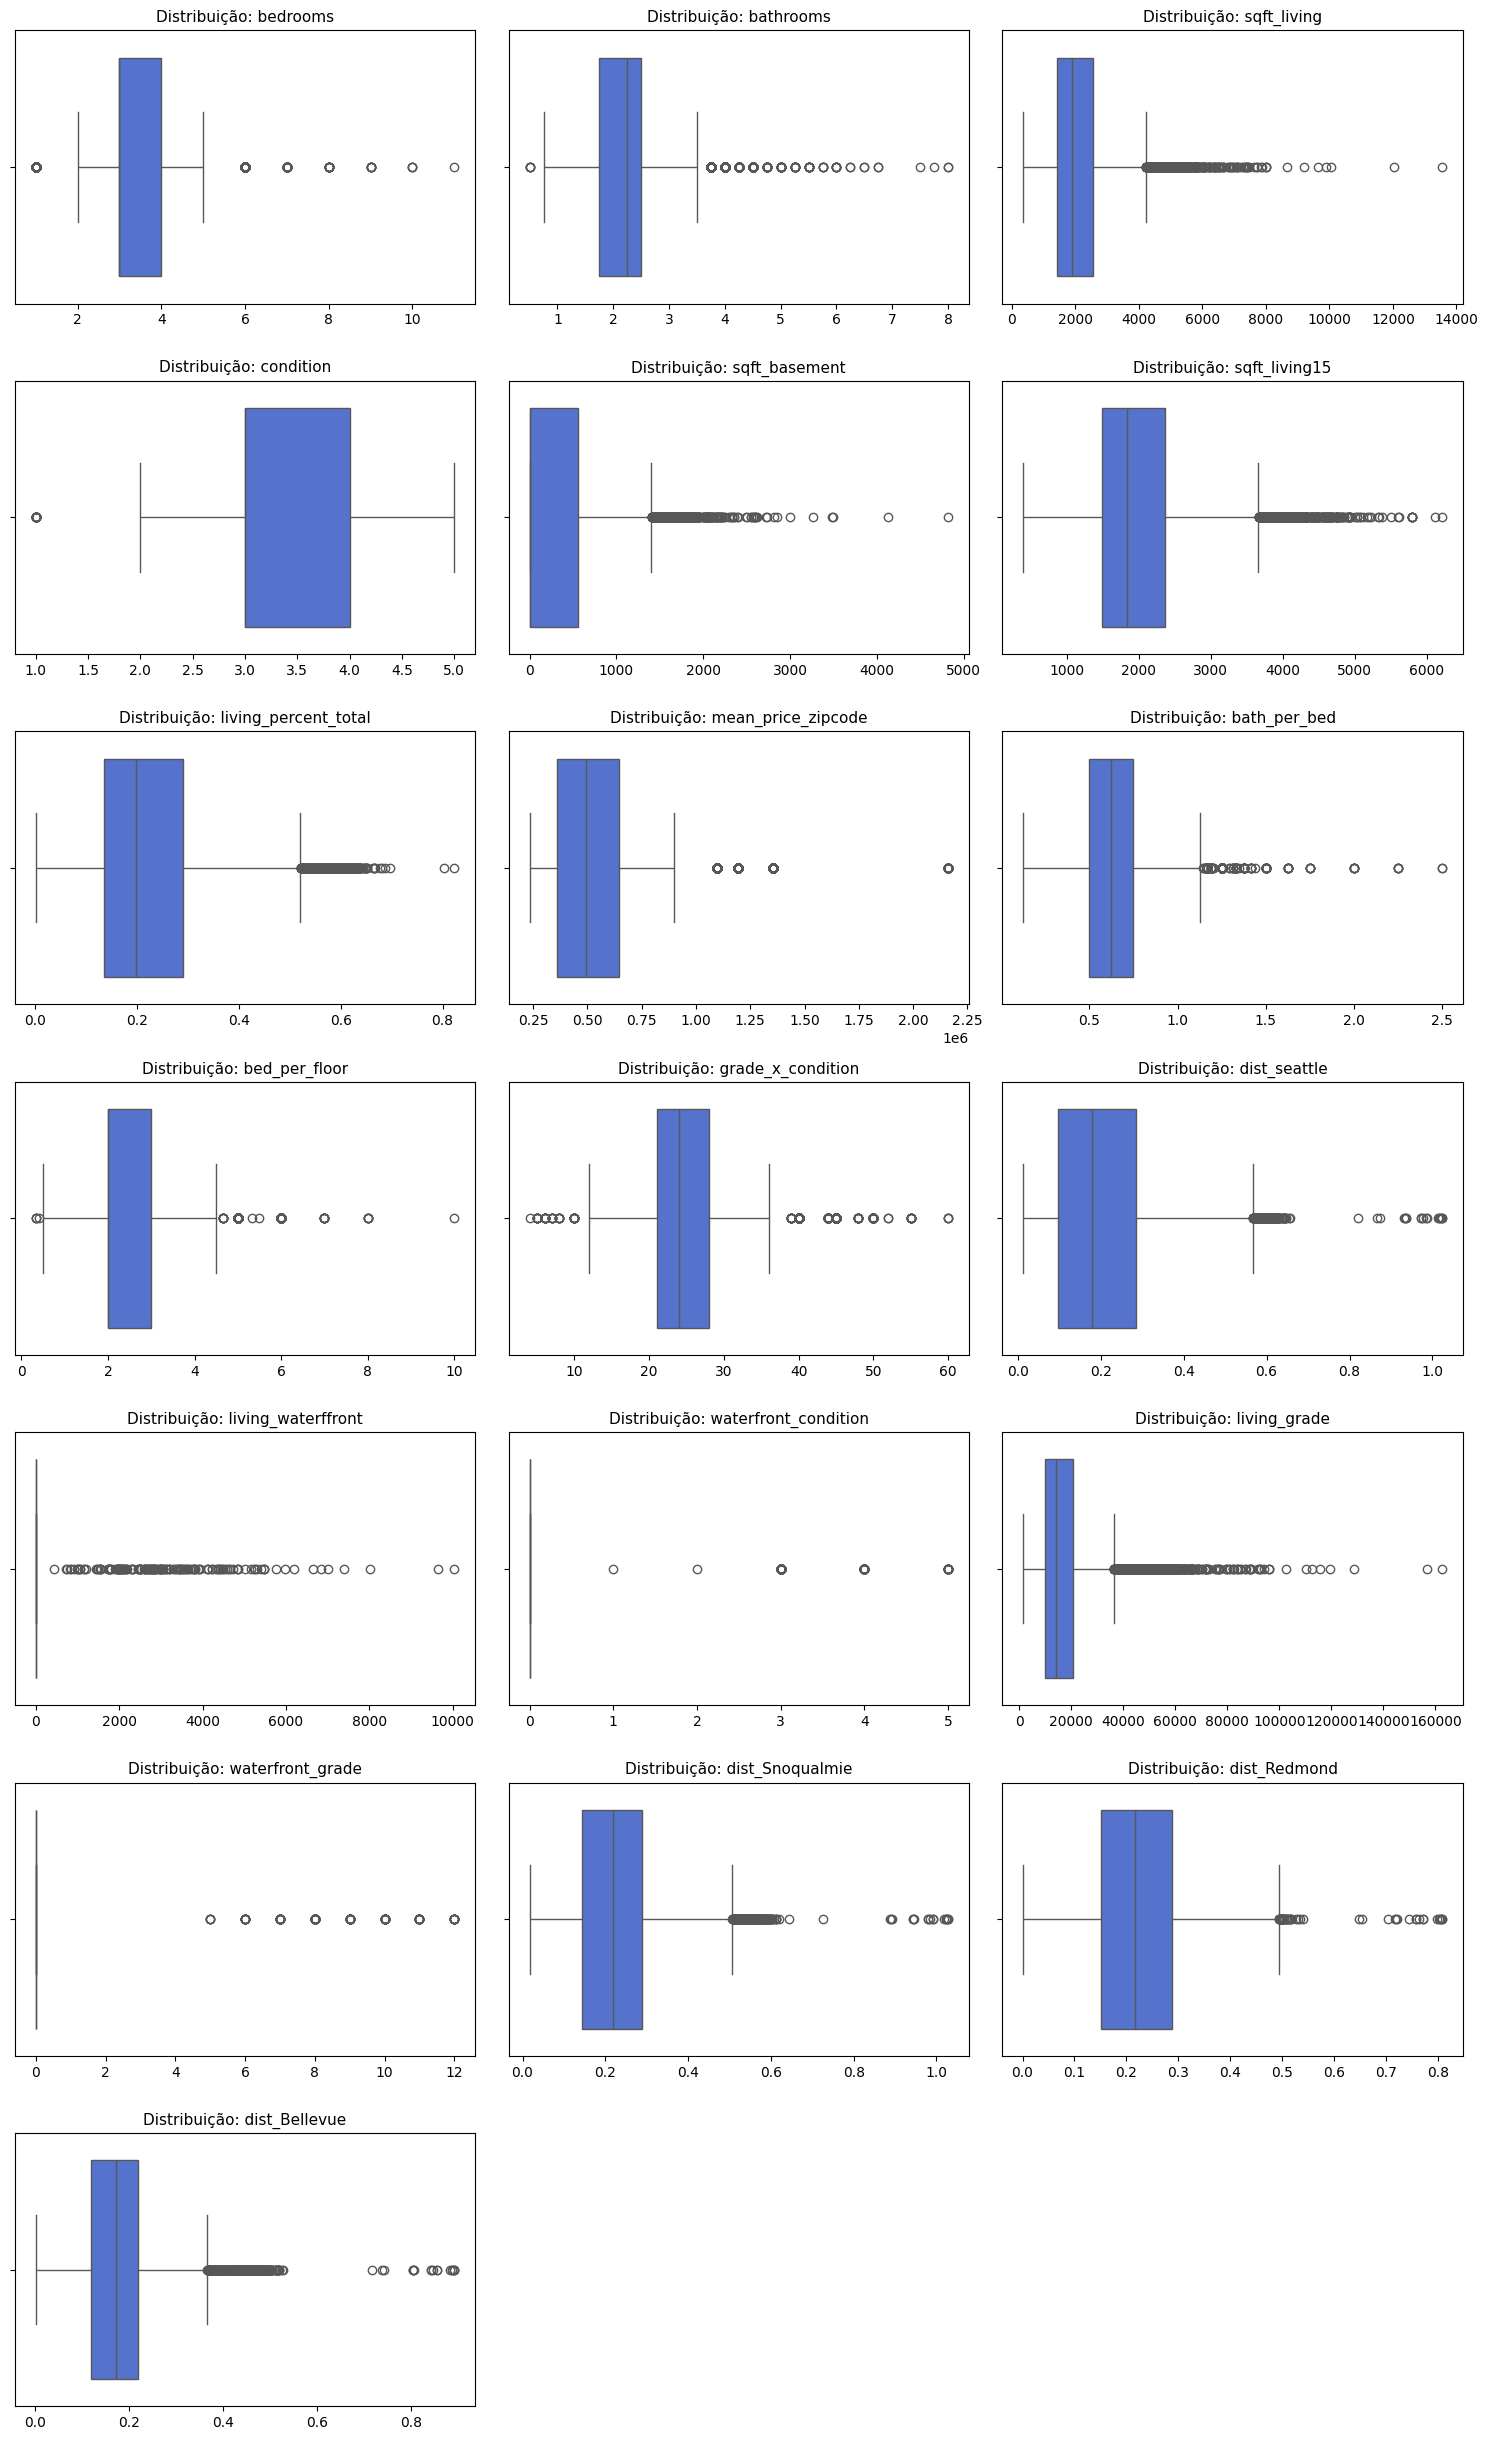

In [20]:
# Conferindo ditribuição geral dos dados e valores extremos

lista_extremos = ['bedrooms',
  'bathrooms',
  'sqft_living',
  'condition',
  'sqft_basement',
  'sqft_living15',
  'living_percent_total',
  'mean_price_zipcode',
  'bath_per_bed',
  'bed_per_floor',
  'grade_x_condition',
  'dist_seattle',
  'living_waterffront',
  'waterfront_condition',
  'living_grade',
  'waterfront_grade',
  'dist_Snoqualmie',
  'dist_Redmond',
  'dist_Bellevue']

cols_por_linha = 3
qtd_linhas = math.ceil(len(lista_extremos) / cols_por_linha)

fig, axes = plt.subplots(qtd_linhas, cols_por_linha, figsize=(15, qtd_linhas * 3.5))
axes = axes.flatten()

for i, col in enumerate(lista_extremos):
    sns.boxplot(x=df_heatmap[col], ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribuição: {col}', fontsize=11)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [21]:
# Confirmando valores extremos
df_heatmap[lista_extremos].describe(percentiles=[0.5, 0.95, 0.99, 0.999]).T[['min', '50%', '95%', '99%', '99.9%', 'max']]

,min,50%,95%,99%,99.9%,max
bedrooms,1.0000,3.0000,5.000000,6.000000e+00,8.000000e+00,1.100000e+01
bathrooms,0.5000,2.2500,3.500000,4.250000e+00,5.500000e+00,8.000000e+00
sqft_living,370.0000,1910.0000,3760.000000,4.980000e+03,7.290250e+03,1.354000e+04
condition,1.0000,3.0000,5.000000,5.000000e+00,5.000000e+00,5.000000e+00
sqft_basement,0.0000,0.0000,1190.000000,1.660000e+03,2.372150e+03,4.820000e+03
sqft_living15,399.0000,1840.0000,3300.000000,4.080000e+03,5.012150e+03,6.210000e+03
living_percent_total,0.0006,0.1985,0.471300,5.766050e-01,6.390645e-01,8.231000e-01
mean_price_zipcode,234284.0352,493552.5321,879623.623900,1.355927e+06,2.160607e+06,2.160607e+06
bath_per_bed,0.1250,0.6250,1.000000,1.250000e+00,1.625000e+00,2.500000e+00
bed_per_floor,0.3333,2.0000,4.000000,5.000000e+00,6.000000e+00,1.000000e+01


In [24]:
obter_listas_tratamento(df_step_1)

{'log': ['price',
  'sqft_lot',
  'waterfront',
  'view',
  'sqft_basement',
  'sqft_lot15',
  'final_de_semana',
  'fim_do_mes',
  'estacao_Inverno',
  'lot_15_compare',
  'living_15_compare',
  'mean_price_zipcode',
  'bool_renovated',
  'living_more_than_lot',
  'bool_renovated_15',
  'waterfront_grade',
  'living_grade',
  'living_waterffront',
  'waterfront_condition',
  'luxury'],
 'capping': ['price',
  'sqft_lot',
  'view',
  'grade',
  'sqft_lot15',
  'estacao_Outono',
  'estacao_Inverno',
  'lot_15_compare',
  'living_15_compare',
  'bool_renovated_15',
  'luxury'],
 'extremos': ['bedrooms',
  'bathrooms',
  'sqft_living',
  'waterfront',
  'condition',
  'sqft_basement',
  'sqft_living15',
  'final_de_semana',
  'fim_do_mes',
  'living_percent_total',
  'mean_price_zipcode',
  'bath_per_bed',
  'bed_per_floor',
  'grade_x_condition',
  'bool_renovated',
  'living_more_than_lot',
  'dist_seattle',
  'dist_Bellevue',
  'dist_Redmond',
  'dist_Snoqualmie',
  'waterfront_grade',

In [23]:
df_step_2 = df_step_1.copy()

In [25]:
# Tratando o Log
colunas_log_sem_bool = ['price',
  'sqft_lot',
  'waterfront',
  'view',
  'sqft_basement',
  'sqft_lot15',
  'final_de_semana',
  'fim_do_mes',
  'estacao_Inverno',
  'lot_15_compare',
  'living_15_compare',
  'mean_price_zipcode',
  'bool_renovated',
  'living_more_than_lot',
  'bool_renovated_15',
  'waterfront_grade',
  'living_grade',
  'living_waterffront',
  'waterfront_condition',
  'luxury']

for col in colunas_log_sem_bool:
    if df_step_2[col].nunique() <= 5:
      continue
    else:
      df_step_2[f'{col}_log'] = np.log1p(df_step_2[col])
      df_step_2.drop(columns=[col], inplace=True)

In [26]:
df_step_2

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,sqft_living15,ano,...,sqft_basement_log,sqft_lot15_log,lot_15_compare_log,living_15_compare_log,mean_price_zipcode_log,waterfront_grade_log,living_grade_log,living_waterffront_log,waterfront_condition_log,luxury_log
0,3,1.00,1180,1.0,0,0,3,7,1340,2014,...,0.000000,8.639588,0.693147,0.631591,12.646305,0.0,9.019301,0.0,0.0,22.764094
1,3,2.25,2570,2.0,0,0,3,7,1690,2014,...,5.993961,8.941153,0.666803,0.924537,13.059331,0.0,9.797627,0.0,0.0,23.955513
2,2,1.00,770,1.0,0,0,3,6,2720,2015,...,0.000000,8.995041,0.806654,0.249279,13.044361,0.0,8.438366,0.0,0.0,22.581121
3,4,3.00,1960,1.0,0,0,5,7,1360,2014,...,6.814543,8.517393,0.693147,0.892490,13.220741,0.0,9.526683,0.0,0.0,24.356787
4,3,2.00,1680,1.0,0,0,3,8,1800,2015,...,0.000000,8.923191,0.730876,0.659228,13.438060,0.0,9.506065,0.0,0.0,24.042661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21607,3,2.50,1530,3.0,0,0,3,8,1530,2014,...,0.000000,7.319865,0.559330,0.693147,13.279074,0.0,9.412546,0.0,0.0,23.790149
21608,4,2.50,2310,2.0,0,0,3,8,1830,2015,...,0.000000,8.881975,0.591889,0.816382,12.792426,0.0,9.824498,0.0,0.0,23.715479
21609,2,0.75,1020,2.0,0,0,3,7,1020,2014,...,0.000000,7.604894,0.514379,0.693147,13.295558,0.0,8.873608,0.0,0.0,23.267636
21610,3,2.50,1600,2.0,0,0,3,8,1410,2015,...,0.000000,7.160846,1.049247,0.758373,13.332611,0.0,9.457279,0.0,0.0,23.888422


In [27]:
criar_painel_diagnostico(df_step_2)

,Coluna,Assimetria (Skew),Precisa de LOG?,Qtd Outliers,% Outliers,Possível Ruído?,Ação Recomendada
19,estacao_Outono,1.26,Não,5056,23.41,Não,Suavizar Outliers (Capping)
39,lot_15_compare_log,4.79,SIM,3882,17.98,Não,Aplicar LOG + Suavizar Outliers (Capping)
20,estacao_Inverno,1.75,SIM,3695,17.11,Não,Aplicar LOG + Suavizar Outliers (Capping)
36,sqft_lot_log,0.96,Não,2554,11.83,Não,Suavizar Outliers (Capping)
38,sqft_lot15_log,0.97,Não,2487,11.52,Não,Suavizar Outliers (Capping)
5,view,3.40,SIM,2122,9.83,Não,Aplicar LOG + Suavizar Outliers (Capping)
7,grade,0.79,Não,1905,8.82,Não,Suavizar Outliers (Capping)
40,living_15_compare_log,0.84,Não,1415,6.55,Não,Suavizar Outliers (Capping)
34,bool_renovated_15,4.04,SIM,1123,5.20,Não,Aplicar LOG + Suavizar Outliers (Capping)
27,bool_renovated,4.55,SIM,914,4.23,Não,Aplicar LOG + Checar Extremos


In [28]:
df_step_2.to_csv('df_eng_feat.csv', index=False, sep=';', encoding='utf-8-sig')

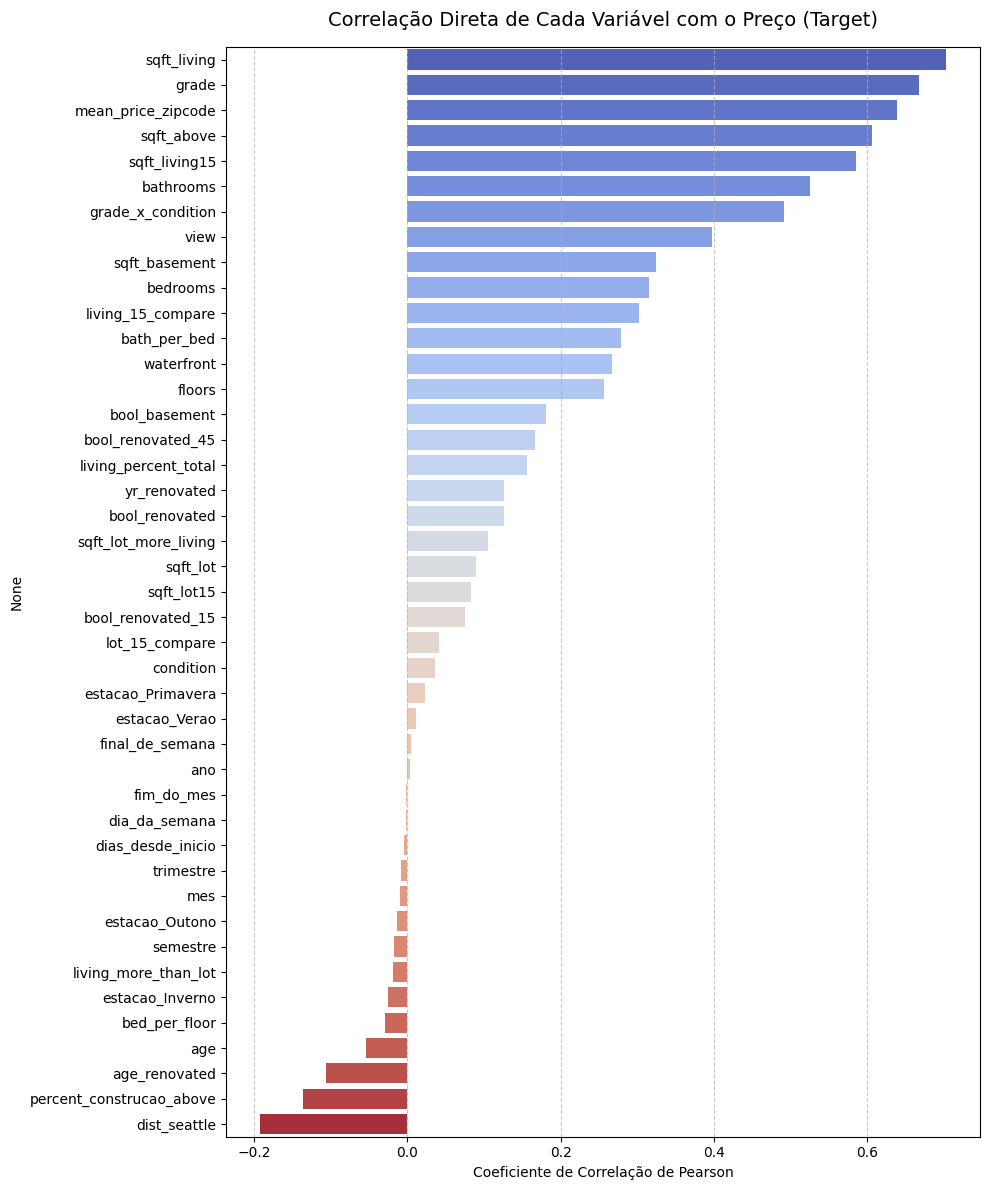

In [27]:
# Filtra apenas a correlação com o preço e ordena do maior para o menor
price_corr = corr['price'].sort_values(ascending=False).drop('price')

plt.figure(figsize=(10, 12))

sns.barplot(
    x=price_corr.values, 
    y=price_corr.index, 
    hue=price_corr.index, 
    palette='coolwarm', 
    legend=False)

plt.title('Correlação Direta de Cada Variável com o Preço (Target)', fontsize=14, pad=15)
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()